Используйте датасет Credit Card Default Prediction (предсказание дефолта по кредитной карте), доступный по ссылке:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Целевая переменная: default.payment.next.month (дефолт в следующем месяце).
Признаки: демографические данные, история платежей, сумма кредита и др.



In [1]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print(f"Путь к датасету: {path}")


import os
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            break

Using Colab cache for faster access to the 'default-of-credit-card-clients-dataset' dataset.
Путь к датасету: /kaggle/input/default-of-credit-card-clients-dataset


Задача 1. Подготовка данных и базовое моделирование (1 балла)
- Загрузите датасет, разделите на обучающую и тестовую выборки (80/20).

- Обучите модель CatBoostClassifier с параметрами по умолчанию.

- Оцените качество модели с помощью ROC-AUC на тесте.

In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


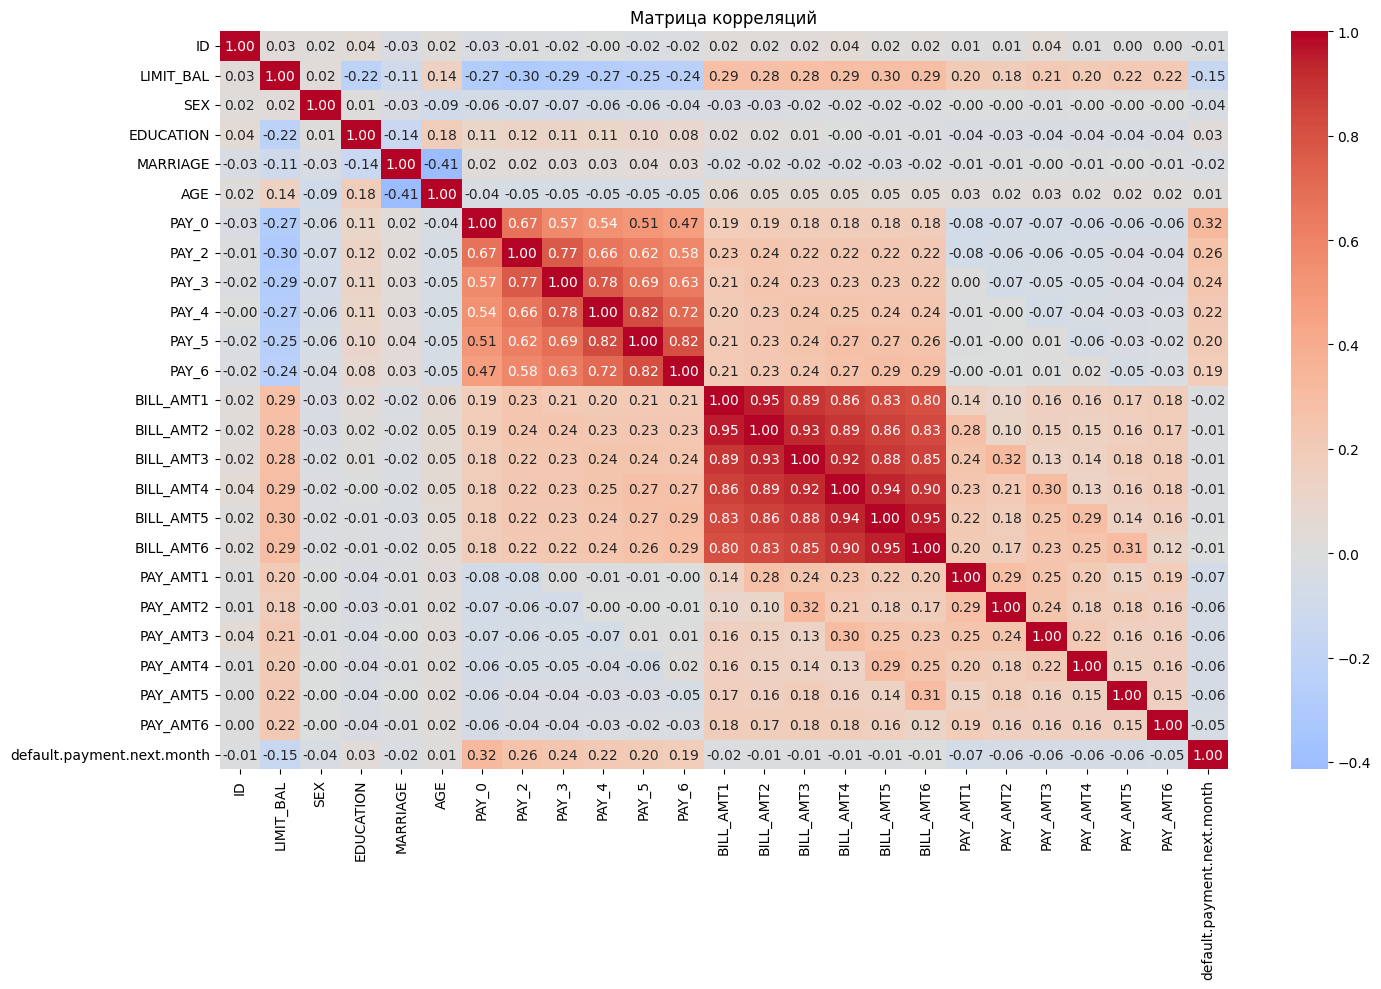

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['default.payment.next.month']), df['default.payment.next.month'],
                                                    test_size=0.2, random_state=42, stratify=df['default.payment.next.month'])
X_train.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
22788,22789,160000.0,2,2,2,33,2,2,3,2,...,168541.0,164310.0,162681.0,163005.0,15000.0,0.0,0.0,6100.0,12300.0,6100.0
29006,29007,150000.0,2,1,2,34,1,-1,-1,-2,...,0.0,0.0,0.0,0.0,53.0,0.0,0.0,0.0,0.0,0.0
16950,16951,10000.0,1,2,1,50,1,2,0,0,...,8446.0,8067.0,8227.0,8400.0,2.0,1281.0,1134.0,294.0,305.0,1000.0
22280,22281,220000.0,2,1,2,29,0,0,0,0,...,215139.0,218513.0,131660.0,134346.0,9100.0,9000.0,7887.0,4800.0,4900.0,6000.0
11346,11347,310000.0,2,1,2,32,1,-2,-1,0,...,326.0,326.0,-235.0,-235.0,0.0,326.0,0.0,0.0,0.0,1200.0


In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [15]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

model = CatBoostClassifier(random_seed=42, verbose=100)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('ROC-AUC', roc_auc)

Learning rate set to 0.040021
0:	learn: 0.6707186	total: 36.4ms	remaining: 36.4s
100:	learn: 0.4186212	total: 2.66s	remaining: 23.7s
200:	learn: 0.4075246	total: 5.03s	remaining: 20s
300:	learn: 0.3976786	total: 7.29s	remaining: 16.9s
400:	learn: 0.3882738	total: 9.52s	remaining: 14.2s
500:	learn: 0.3794445	total: 12.6s	remaining: 12.6s
600:	learn: 0.3711615	total: 15.4s	remaining: 10.2s
700:	learn: 0.3627133	total: 17.7s	remaining: 7.57s
800:	learn: 0.3552934	total: 18.9s	remaining: 4.69s
900:	learn: 0.3476411	total: 20.1s	remaining: 2.2s
999:	learn: 0.3404923	total: 21.2s	remaining: 0us
ROC-AUC 0.7771136631075503


Задача 2. Оценка важности признаков (2 балла)
- Встроенная важность CatBoost (PredictionValuesChange) используйте get_feature_importance() для получения важности признаков, основанной на изменении предсказаний.

- Permutation Importance,используйте sklearn.inspection.permutation_importance. Постройте боксплот важности признаков.

- SHAP-анализ, используйте SHAP-значения для тестовой выборки.Постройте summary plot (bar и dot). Выберите одно наблюдение и объясните его предсказание с помощью shap.force_plot

Важно! Вычисляйте важность на обучающей или валидационной выборке, но не на тестовой. Тестовая выборка используется только для финальной оценки модели.

Задача 3. Выводы (1 балла)
- Сравните топ-5 важных признаков по каждому методу.

- Найдите признаки, которые важны во всех методах;важны только в одном методе; имеют отрицательную важность в Permutation Importance.

- Объясните, почему методы могут давать разные результаты.

Ответ:

Задача 4. Отбор признаков (2 балла)

- Определите порог важности (например, важность случайного признака) и удалите менее важные признаки.

- Обучите модель на сокращённом наборе признаков и сравните ROC-AUC с исходной моделью.

- Можно ли сократить количество признаков без потери качества?

Ответ:

Задача 5. Анализ с добавленными случайными признаками (4 балла)

- Добавьте 10 случайных нормально распределенных признаков в датасет.

- Выполните оценку важности признаков (как в задаче 2) и проанализируйте, как методы ранжируют случайные признаки.

- Выполните отбор признаков с разными порогами 0%, 25%, 50%, 75% наименее важных признаков (удаляйте).

- Для каждого порога обучите модель и оцените ROC-AUC на тесте.

- Постройте график зависимости ROC-AUC от количества удаленных признаков.

- Проанализируйте, как изменяется качество модели при удалении разных долей признаков.
